In [14]:
import numpy as np
import pandas as pd

RUTA_DATOS = "data/datos_preprocesados.csv"
PAGOS_POR_ANIO = 12   # Dado que la duración de los préstamos se expresa en meses, se considera una periodicidad mensual de las cuotas, equivalente a 12 pagos anuales.


def cargar_prestamos(ruta: str) -> pd.DataFrame:
    "Lee el dataset preprocesado y selecciona las columnas necesarias."
    prestamos = pd.read_csv(ruta)
    prestamos = prestamos[["ID", "Monto_Inicial", "Ratio_Interes", "Duracion", "Ingresos"]]
    return prestamos


def expandir_periodos(prestamos: pd.DataFrame) -> pd.DataFrame:
    "Repite cada préstamo una vez por cada mes de su duración y numera los periodos."
    cuadro = prestamos.loc[prestamos.index.repeat(prestamos["Duracion"])].copy()
    cuadro["Periodo"] = cuadro.groupby(level=0).cumcount() + 1
    return cuadro


prestamos = cargar_prestamos(RUTA_DATOS)
prestamos.head()

,ID,Monto_Inicial,Ratio_Interes,Duracion,Ingresos
0,KG9CT9,73978,13.91,60,56572
1,V5O0K9,150000,10.53,24,68698
2,YE5GD0,7490,9.24,60,50000
3,Q6HQ3D,11801,7.63,48,63033
4,XO8CO4,40000,8.40,36,22301


### Fórmulas del Sistema Francés

In [15]:
def cuadro_frances(prestamos: pd.DataFrame) -> pd.DataFrame:
    cuadro_fr = expandir_periodos(prestamos)

    C = cuadro_fr["Monto_Inicial"]                          
    N = cuadro_fr["Duracion"]                               
    n = cuadro_fr["Periodo"]                                
    i = cuadro_fr["Ratio_Interes"] / 100 / PAGOS_POR_ANIO   

    # Cuota fija
    cuadro_fr["Cuota"] = C * i / (1 - (1 + i) ** -N)

    # Saldo pendiente tras n pagos
    cuadro_fr["Saldo_Final"] = C * ((1 + i) ** N - (1 + i) ** n) / ((1 + i) ** N - 1)
    cuadro_fr["Saldo_Inicial"] = C * ((1 + i) ** N - (1 + i) ** (n - 1)) / ((1 + i) ** N - 1)

    # Intereses sobre el saldo pendiente, el resto de la cuota amortiza capital
    cuadro_fr["Intereses"] = cuadro_fr["Saldo_Inicial"] * i
    cuadro_fr["Capital_Amortizado"] = cuadro_fr["Cuota"] - cuadro_fr["Intereses"]

    return cuadro_fr

In [16]:
cuadro_fr = cuadro_frances(prestamos)
cuadro_fr.head()

,ID,Monto_Inicial,Ratio_Interes,Duracion,Ingresos,Periodo,Cuota,Saldo_Final,Saldo_Inicial,Intereses,Capital_Amortizado
0,KG9CT9,73978,13.91,60,56572,1,1717.888844,73117.639472,73978.000000,857.528317,860.360528
0,KG9CT9,73978,13.91,60,56572,2,1717.888844,72247.305932,73117.639472,847.555304,870.333540
0,KG9CT9,73978,13.91,60,56572,3,1717.888844,71366.883776,72247.305932,837.466688,880.422156
0,KG9CT9,73978,13.91,60,56572,4,1717.888844,70476.256060,71366.883776,827.261128,890.627716
0,KG9CT9,73978,13.91,60,56572,5,1717.888844,69575.304484,70476.256060,816.937268,900.951576


### Fórmulas del sistema alemán

In [17]:
def cuadro_aleman(prestamos: pd.DataFrame) -> pd.DataFrame:
    cuadro_al = expandir_periodos(prestamos)

    C = cuadro_al["Monto_Inicial"]
    N = cuadro_al["Duracion"]
    n = cuadro_al["Periodo"]
    i = cuadro_al["Ratio_Interes"] / 100 / PAGOS_POR_ANIO

    # Capital amortizado constante
    cuadro_al["Capital_Amortizado"] = C / N

    # Saldo pendiente antes y después de cada pago
    cuadro_al["Saldo_Inicial"] = C - cuadro_al["Capital_Amortizado"] * (n - 1)
    cuadro_al["Saldo_Final"] = C - cuadro_al["Capital_Amortizado"] * n

    # Intereses sobre el saldo pendiente
    cuadro_al["Intereses"] = cuadro_al["Saldo_Inicial"] * i

    # La cuota es capital amortizado + intereses
    cuadro_al["Cuota"] = cuadro_al["Capital_Amortizado"] + cuadro_al["Intereses"]

    return cuadro_al

### Comprobación: Vemos que al final de cada préstamo la cantidad a amortizar sea 0

In [18]:
ultimas_cuotas_fr = cuadro_fr[cuadro_fr["Periodo"] == cuadro_fr["Duracion"]]
saldo_maximo_fr = ultimas_cuotas_fr["Saldo_Final"].abs().max()

if saldo_maximo_fr < 0.01:
    print("Todos los préstamos quedan amortizados con el sistema francés (saldo final = 0)")
else:
    print("Revisar: hay préstamos con saldo final distinto de 0")

Todos los préstamos quedan amortizados con el sistema francés (saldo final = 0)


In [19]:
cuadro_al = cuadro_aleman(prestamos)

In [20]:
ultimas_cuotas_al = cuadro_al[cuadro_al["Periodo"] == cuadro_al["Duracion"]]
saldo_maximo_al = ultimas_cuotas_al["Saldo_Final"].abs().max()

if saldo_maximo_al < 0.01:
    print("Todos los préstamos quedan amortizados con el sistema alemán (saldo final = 0)")
else:
    print("Revisar: hay préstamos con saldo final distinto de 0")

Todos los préstamos quedan amortizados con el sistema alemán (saldo final = 0)


### Ejemplo con el primer cliente del dataset

In [21]:
cuadro_fr.loc[0, ["Periodo", "Cuota", "Intereses", "Capital_Amortizado", "Saldo_Final"]].round(2)

,Periodo,Cuota,Intereses,Capital_Amortizado,Saldo_Final
0,1,1717.89,857.53,860.36,73117.64
0,2,1717.89,847.56,870.33,72247.31
0,3,1717.89,837.47,880.42,71366.88
0,4,1717.89,827.26,890.63,70476.26
0,5,1717.89,816.94,900.95,69575.30
0,6,1717.89,806.49,911.40,68663.91
0,7,1717.89,795.93,921.96,67741.95
0,8,1717.89,785.24,932.65,66809.30
0,9,1717.89,774.43,943.46,65865.85
0,10,1717.89,763.49,954.39,64911.45


In [22]:
cuadro_al.loc[0, ["Periodo", "Cuota", "Intereses", "Capital_Amortizado", "Saldo_Final"]].round(2)

,Periodo,Cuota,Intereses,Capital_Amortizado,Saldo_Final
0,1,2090.49,857.53,1232.97,72745.03
0,2,2076.20,843.24,1232.97,71512.07
0,3,2061.91,828.94,1232.97,70279.10
0,4,2047.62,814.65,1232.97,69046.13
0,5,2033.33,800.36,1232.97,67813.17
0,6,2019.03,786.07,1232.97,66580.20
0,7,2004.74,771.78,1232.97,65347.23
0,8,1990.45,757.48,1232.97,64114.27
0,9,1976.16,743.19,1232.97,62881.30
0,10,1961.87,728.90,1232.97,61648.33


### Comparación entre los sistemas francés y alemán

#### Resumen sistema francés

In [24]:
resumen_fr = cuadro_fr.groupby("ID").agg(
    Primera_Cuota_Fr=("Cuota", "first"),
    Ultima_Cuota_Fr=("Cuota", "last"),
    Cuota_Maxima_Fr=("Cuota", "max"),
    Intereses_Totales_Fr=("Intereses", "sum"),
    Total_Pagado_Fr=("Cuota", "sum")
).reset_index()

#### Resumen sistema alemán

In [25]:
resumen_al = cuadro_al.groupby("ID").agg(
    Primera_Cuota_Al=("Cuota", "first"),
    Ultima_Cuota_Al=("Cuota", "last"),
    Cuota_Maxima_Al=("Cuota", "max"),
    Intereses_Totales_Al=("Intereses", "sum"),
    Total_Pagado_Al=("Cuota", "sum")
).reset_index()

#### Juntamos

In [27]:
comparacion = resumen_fr.merge(resumen_al, on="ID")

In [28]:
comparacion = comparacion.merge(
    prestamos[["ID", "Ingresos"]],
    on="ID"
)

#### Esfuerzo de la primera cuota

In [29]:
comparacion["Ingreso_Mensual"] = comparacion["Ingresos"] / 12

comparacion["Esfuerzo_Inicial_Fr"] = (
    comparacion["Primera_Cuota_Fr"] /
    comparacion["Ingreso_Mensual"] * 100
)

comparacion["Esfuerzo_Inicial_Al"] = (
    comparacion["Primera_Cuota_Al"] /
    comparacion["Ingreso_Mensual"] * 100
)

In [30]:
comparacion["Ahorro_Intereses_Al"] = (
    comparacion["Intereses_Totales_Fr"] -
    comparacion["Intereses_Totales_Al"]
)

comparacion["Sobreesfuerzo_Inicial_Al"] = (
    comparacion["Primera_Cuota_Al"] -
    comparacion["Primera_Cuota_Fr"]
)

In [32]:
comparacion[[
    "ID",
    "Primera_Cuota_Fr",
    "Primera_Cuota_Al",
    "Esfuerzo_Inicial_Fr",
    "Esfuerzo_Inicial_Al",
    "Intereses_Totales_Fr",
    "Intereses_Totales_Al",
    "Ahorro_Intereses_Al",
    "Sobreesfuerzo_Inicial_Al"
]].head().round(2)

,ID,Primera_Cuota_Fr,Primera_Cuota_Al,Esfuerzo_Inicial_Fr,Esfuerzo_Inicial_Al,Intereses_Totales_Fr,Intereses_Totales_Al,Ahorro_Intereses_Al,Sobreesfuerzo_Inicial_Al
0,000AIY,1541.75,1867.30,36.79,44.55,20332.80,18354.36,1978.44,325.56
1,000OJE,1268.83,1405.44,80.06,88.68,5677.77,5445.17,232.60,136.62
2,000PLV,644.60,729.53,11.18,12.65,4753.80,4507.11,246.69,84.93
3,000Q3U,2696.70,3122.27,64.07,74.18,18703.23,17484.50,1218.73,425.57
4,000TF1,123.38,136.15,9.25,10.21,528.64,507.94,20.70,12.77


In [33]:
comparacion[[
    "Esfuerzo_Inicial_Fr",
    "Esfuerzo_Inicial_Al",
    "Intereses_Totales_Fr",
    "Intereses_Totales_Al"
]].describe()

,Esfuerzo_Inicial_Fr,Esfuerzo_Inicial_Al,Intereses_Totales_Fr,Intereses_Totales_Al
count,178606.000000,178606.000000,178606.000000,178606.000000
mean,50.203621,55.539185,8206.774234,7679.880630
std,55.658764,59.731797,10765.815623,9867.450779
min,1.268485,1.408413,38.488136,38.350000
25%,15.752894,17.772258,2115.552685,2025.945253
50%,32.029721,35.998276,4868.479568,4637.333333
75%,64.134370,71.614682,9939.258818,9334.500000
max,912.165907,984.131390,233451.884865,201503.333333


El sistema alemán exige un mayor esfuerzo al inicio del préstamo. La mediana del esfuerzo inicial es del 36,0 % de los ingresos mensuales, frente al 32,0 % del sistema francés.

Sin embargo, el sistema alemán genera un menor coste total en intereses. La mediana de los intereses pagados es de 4.637,33 € en el sistema alemán, frente a 4.868,48 € en el sistema francés.

Por tanto, el sistema francés facilita el pago al comienzo del préstamo, mientras que el alemán reduce el coste financiero total.

In [34]:
comparacion[[
    "Ahorro_Intereses_Al",
    "Sobreesfuerzo_Inicial_Al"
]].describe()

,Ahorro_Intereses_Al,Sobreesfuerzo_Inicial_Al
count,178606.000000,178606.000000
mean,526.893604,182.097255
std,964.370833,208.476467
min,0.123806,2.426455
25%,70.419896,55.425050
50%,217.049967,124.413494
75%,581.309868,216.637178
max,31948.551532,3280.584128


El sistema alemán supone una primera cuota superior a la del sistema francés, pero permite ahorrar intereses durante la vida del préstamo.

La mediana del sobreesfuerzo inicial es de aproximadamente 124,41 €, mientras que la mediana del ahorro total en intereses es de aproximadamente 217,05 €.

Los valores máximos son mucho más elevados que los valores centrales, por lo que la distribución presenta casos extremos. Por este motivo, la mediana resulta más representativa que la media para describir el comportamiento habitual de los préstamos.

In [35]:
comparacion["Diferencia_Esfuerzo"] = (
    comparacion["Esfuerzo_Inicial_Al"]
    - comparacion["Esfuerzo_Inicial_Fr"]
)

In [36]:
comparacion[[
    "Esfuerzo_Inicial_Fr",
    "Esfuerzo_Inicial_Al",
    "Diferencia_Esfuerzo",
    "Ahorro_Intereses_Al"
]].describe()

,Esfuerzo_Inicial_Fr,Esfuerzo_Inicial_Al,Diferencia_Esfuerzo,Ahorro_Intereses_Al
count,178606.000000,178606.000000,178606.000000,178606.000000
mean,50.203621,55.539185,5.335564,526.893604
std,55.658764,59.731797,5.329493,964.370833
min,1.268485,1.408413,0.058192,0.123806
25%,15.752894,17.772258,1.733665,70.419896
50%,32.029721,35.998276,3.562465,217.049967
75%,64.134370,71.614682,7.011671,581.309868
max,912.165907,984.131390,71.965483,31948.551532


El sistema alemán aumenta el esfuerzo inicial respecto al francés en todos los préstamos analizados.

La diferencia mediana entre ambos sistemas es de aproximadamente 3,56 puntos porcentuales de los ingresos mensuales. Esto confirma que el principal inconveniente del sistema alemán es una mayor exigencia de pago al comienzo del préstamo.

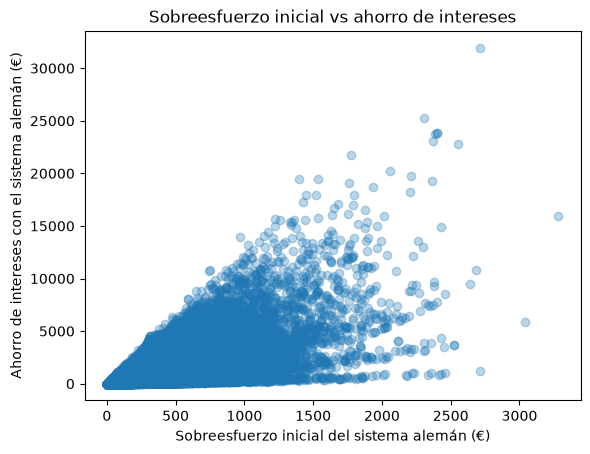

In [37]:
import matplotlib.pyplot as plt

plt.scatter(
    comparacion["Sobreesfuerzo_Inicial_Al"],
    comparacion["Ahorro_Intereses_Al"],
    alpha=0.3
)

plt.xlabel("Sobreesfuerzo inicial del sistema alemán (€)")
plt.ylabel("Ahorro de intereses con el sistema alemán (€)")
plt.title("Sobreesfuerzo inicial vs ahorro de intereses")
plt.show()

El gráfico permite observar el equilibrio entre el mayor pago inicial exigido por el sistema alemán y el ahorro de intereses que genera.

En general, los préstamos en los que el sistema alemán exige un mayor esfuerzo inicial también presentan un mayor ahorro potencial en intereses. No obstante, existen valores extremos, por lo que la elección del sistema no debería basarse únicamente en el ahorro, sino también en la capacidad de pago del prestatario.

## Elección del sistema de amortización